### Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'setup_mc.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


In [2]:
%%time
(root_datasets, pandas_datasets) = load_data(inclmc_type="23903000")
# Uncomments to list columns in the ntuple
#[ str(c) for c in rdf_signal.GetColumnNames() if str(c).startswith("Y_")]

Created df_signal: (9415, 36)
Created df_disp_BsDs: (58395, 36)
Created df_disp_B0Dp: (63133, 36)
Created df_disp_BpD0: (23413, 36)
CPU times: user 9.7 s, sys: 298 ms, total: 10 s
Wall time: 13.7 s


In [3]:
rdf_signal = root_datasets["rdf_signal"]
rdf_disp_BsDs = root_datasets["rdf_disp_BsDs"]
rdf_disp_B0Dp = root_datasets["rdf_disp_B0Dp"]
rdf_disp_BpD0 = root_datasets["rdf_disp_BpD0"]

In [4]:
df_signal = pandas_datasets["df_signal"]
df_disp_BsDs = pandas_datasets["df_disp_BsDs"]
df_disp_B0Dp = pandas_datasets["df_disp_B0Dp"]
df_disp_BpD0 = pandas_datasets["df_disp_BpD0"]

In [5]:
print(f"Nb signal      : {len(df_signal)}")
print(f"Nb BsDs        : {len(df_disp_BsDs)}")
print(f"Nb B0Dp        : {len(df_disp_B0Dp)}")
print(f"Nb BpD0        : {len(df_disp_BpD0)}")
print(f"-------------------------")
print(f"Nb background  : {len(df_disp_BsDs) + len(df_disp_B0Dp) + len(df_disp_BpD0)}")

Nb signal      : 9415
Nb BsDs        : 58395
Nb B0Dp        : 63133
Nb BpD0        : 23413
-------------------------
Nb background  : 144941


In [6]:
# Concatenate and shuffle the backgrounds
from sklearn.utils import shuffle
df_background = pd.concat([df_disp_BsDs, df_disp_B0Dp, df_disp_BpD0], axis=0)
df_background= shuffle(df_background)

# To have equal samples of background and signal
#df_background = df_background.head(df_signal.shape[0])
df = pd.concat([df_signal,df_background], axis=0)
df = shuffle(df)

In [17]:
train_columns = [
"Y_0_40_nc_mult",
"Y_0_20_cc_mult",
"Y_0_20_cc_PZ",
"Y_0_30_nc_PZ",
"Y_0_40_nc_PZ",
"min_m2pi",
"max_m2pi",
"missing_mass_2",
"B_BPVVDR",
"B_M",
"B_correctedMass",
"log(abs(PBsn))",
"log(abs(PBv/B_P))",
"log(abs(PBvn/B_P))",
"log(abs((PBsn-PBvn)/PBvn))",
"log(sqrt(abs(mDs2vn)))",
"mN2v",
"log(Y_PE)",
"BDT_Iso",
"B_pT_Bdir",
"Y_BPVVDR",
"missing_pY_mass",
"Y_correctedMass"]

In [18]:
len(train_columns)

23

# Checking the BDT variables

Y_0_40_nc_mult -> linear
Y_0_20_cc_mult -> linear
Y_0_20_cc_PZ -> log
Y_0_30_nc_PZ -> log
Y_0_40_nc_PZ -> log
min_m2pi -> linear
max_m2pi -> linear
missing_mass_2 -> linear
B_BPVVDR -> linear
B_M -> linear


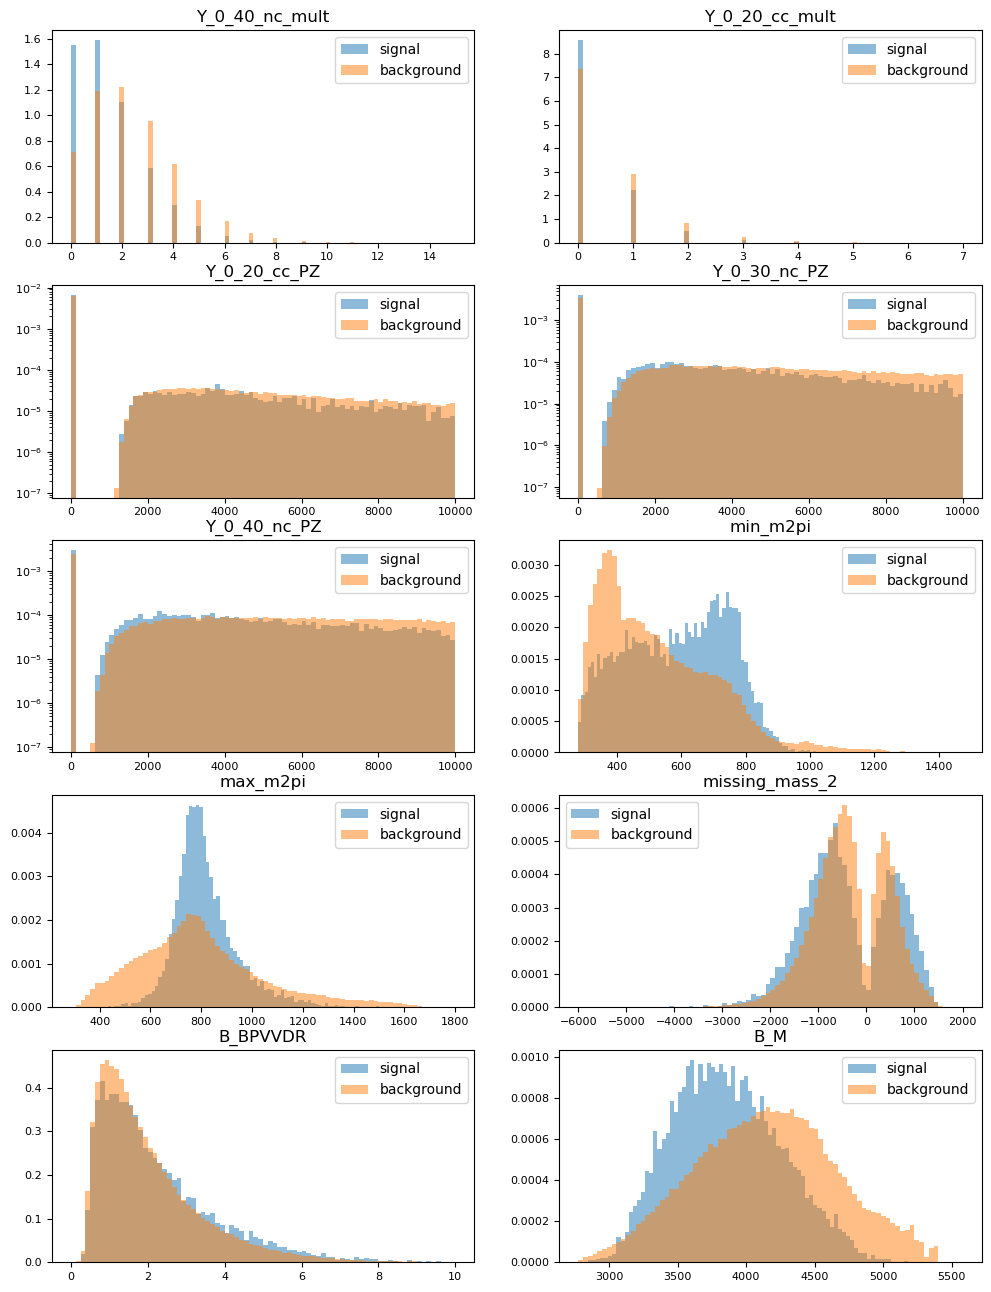

In [54]:
mysize = (12,16)
plt.rcParams["figure.figsize"] = mysize
def hist(ax, *p, **k):
    k |= { 'histtype':'stepfilled', 'bins':80,  'density':True, 'alpha':0.5}
    _, bins, _ = ax.hist(*p, **k)
    ax.legend()

nrow = 5
ncol = 2
cols = train_columns[:nrow * ncol]

mybins = {
    "Y_0_40_nc_mult": 15,
    "Y_0_20_nc_mult": 6,
     "Y_0_20_cc_PZ": 50,
    "Y_0_30_nc_PZ": 50,
    "Y_0_40_nc_PZ": 50,
    
}

myranges = {
    "Y_0_40_nc_mult": [0, 15],
    "Y_0_20_cc_mult": [0, 7],
    "Y_0_20_cc_PZ": [0, 10000],
    "Y_0_30_nc_PZ": [0, 10000],
    "Y_0_40_nc_PZ": [0, 10000],
    "missing_mass_2": [-6000, 2000],
    "log(abs(PBsn))": [7.5, 15],
    "log(abs(PBv/B_P))": [-2, 2],
    "log(abs(PBvn/B_P))": [-2, 2],
    "log(abs((PBsn-PBvn)/PBvn))": [-20, 5],
    "log(sqrt(abs(mDs2vn)))": [5, 10],
    "log(Y_PE)": [9, 13],
    "B_pT_Bdir": [0, 3000],
    "Y_BPVVDR": [0, 11],
    "B_BPVVDR": [0, 10],
    "missing_pY_mass":[-1000, 1200],
    "Y_correctedMass":[0, 3000],
    "B_correctedMass":[2000, 8000],
    "mN2v": [-5e7, 5e7],
}

myscales = {
    "Y_0_20_cc_PZ": "log",
    "Y_0_30_nc_PZ": "log",
    "Y_0_40_nc_PZ": "log",
    "mN2v": "log"
}

import matplotlib 
matplotlib.rc('xtick', labelsize=8) 
matplotlib.rc('ytick', labelsize=8) 

def plot_vars(cols, nrow, ncol):
    fig, axs = plt.subplots(nrow, ncol)
    for i in range(nrow):
        for j in range(ncol):
            ax = None
            if nrow == 1:
                ax = axs[j]
            else:
                ax = axs[i, j]
            k = i *ncol + j
            if k >=  len(cols):
                ax.set_axis_off()
                continue
            ax.set_title(cols[k])
            hist(ax, df_signal[cols[k]], range=myranges.get(cols[k], None), bins=mybins.get(cols[k], None), label="signal")
            hist(ax, df_background[cols[k]], range=myranges.get(cols[k], None), bins=mybins.get(cols[k], None), label="background")
            scale = myscales.get(cols[k], 'linear')
            print(f"{cols[k]} -> {scale}")
            ax.set_yscale(scale)

plot_vars(cols, nrow, ncol)
plt.savefig("BDT_vars_1.png")

B_correctedMass -> linear
log(abs(PBsn)) -> linear
log(abs(PBv/B_P)) -> linear
log(abs(PBvn/B_P)) -> linear
log(abs((PBsn-PBvn)/PBvn)) -> linear
log(sqrt(abs(mDs2vn))) -> linear
mN2v -> log
log(Y_PE) -> linear
BDT_Iso -> linear
B_pT_Bdir -> linear


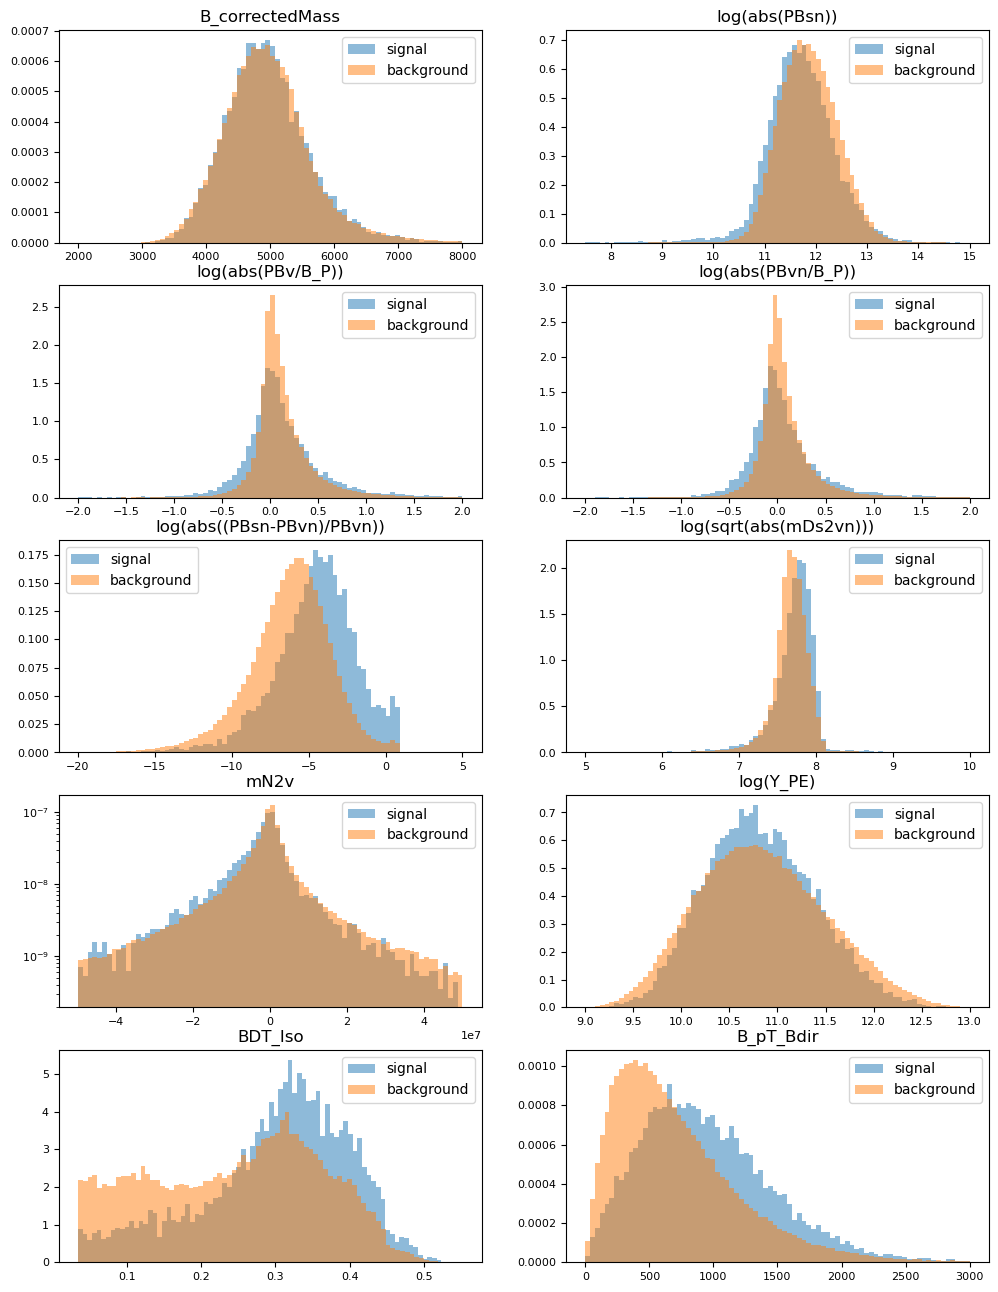

In [55]:
cols = train_columns[10: 10 + nrow * ncol]
plot_vars(cols, nrow, ncol)
plt.savefig("BDT_vars_2.png")

Y_BPVVDR -> linear
missing_pY_mass -> linear
Y_correctedMass -> linear


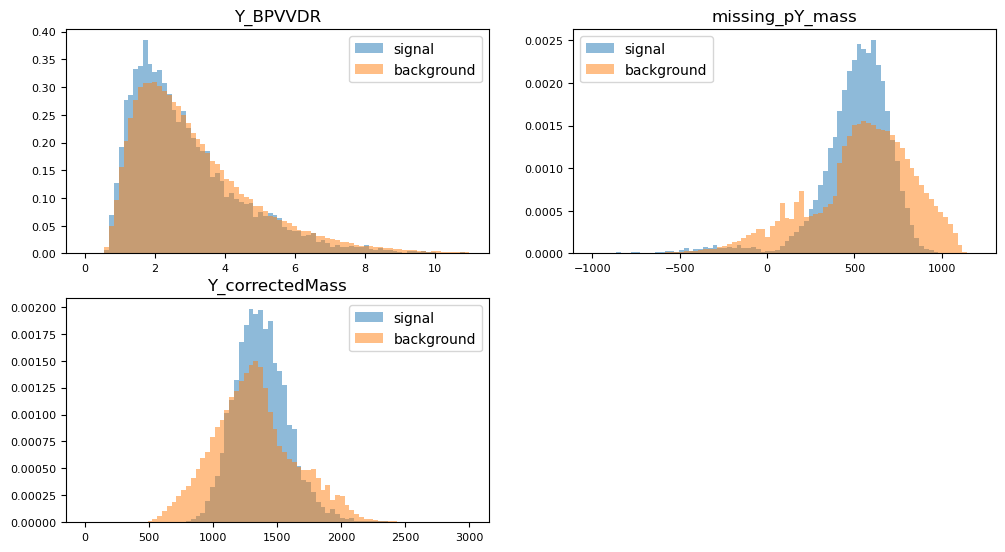

In [56]:

nrow_small = 2
ncol = 2
mysize_small = (mysize[0],   nrow_small/nrow * mysize[1])
plt.rcParams["figure.figsize"] = mysize_small
cols = train_columns[20: 20 + nrow * ncol]
plot_vars(cols, nrow_small, ncol)
plt.savefig("BDT_vars_3.png")

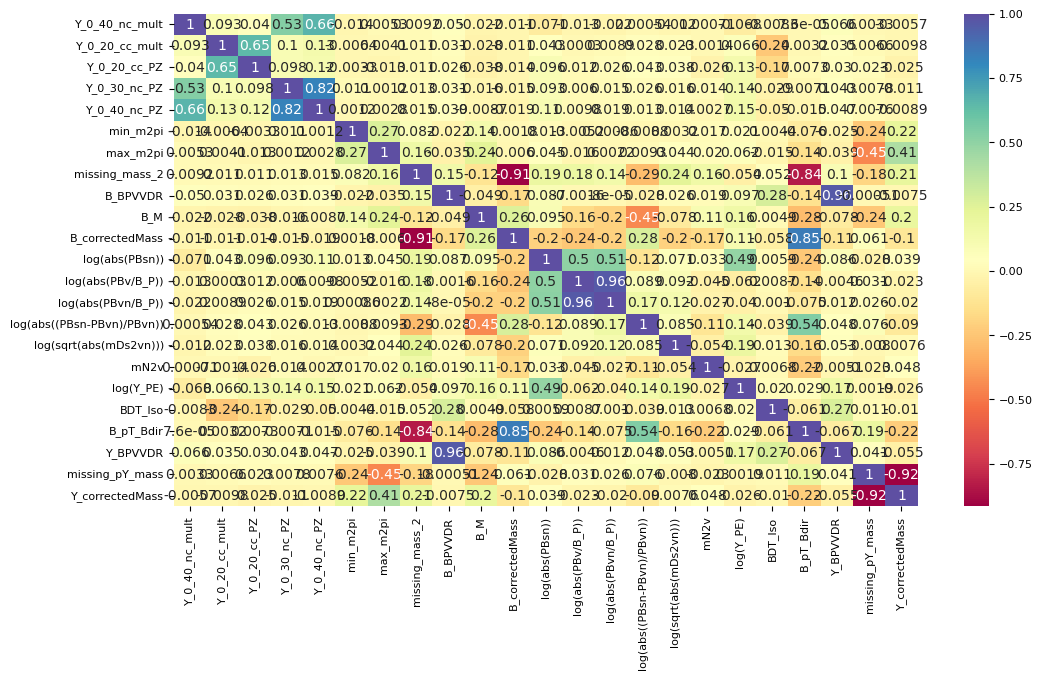

In [57]:
myvars = train_columns
scor = df_signal[myvars].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Spectral);

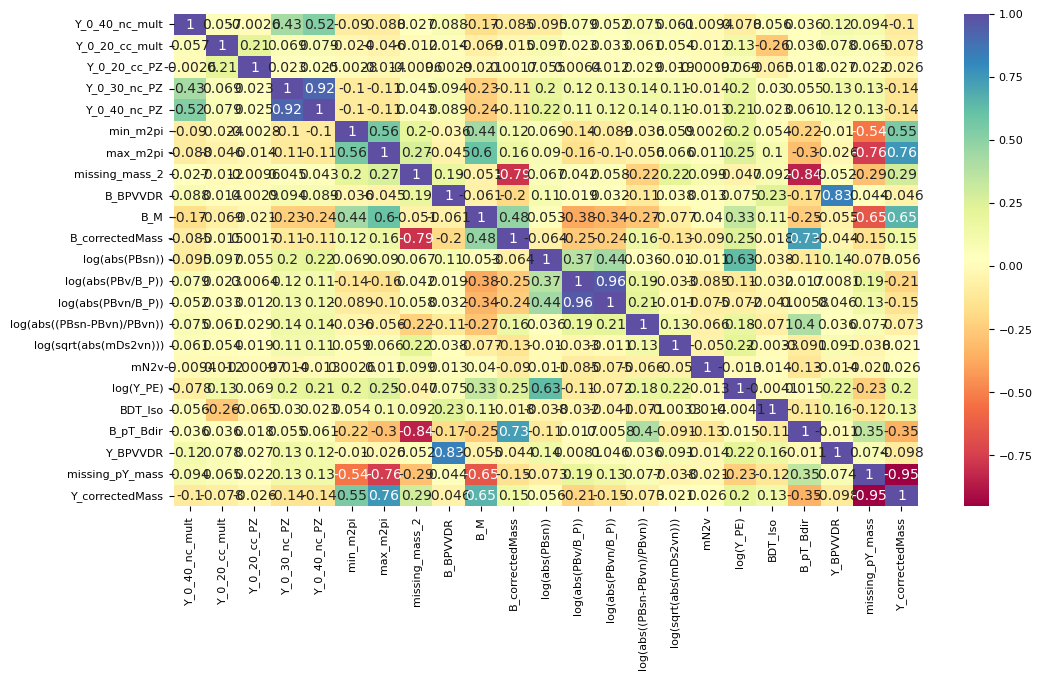

In [58]:
myvars = train_columns
scor = df_background[myvars].corr()
sns.heatmap(scor, annot=True, cmap=plt.cm.Spectral);

In [16]:
29.7 * 12/21


16.97142857142857